# House Price Predictor 🏠

A beginner-friendly machine learning project. We're going to predict median house
prices for neighborhoods in California, using real 1990 census data from Kaggle.

**What you'll see in this notebook, in order:**
1. Load the data
2. Explore it (get a feel for what's in it)
3. Clean it (fix missing values, prepare it for a model)
4. Train three different models
5. Compare which model did best, and why

**No prior ML experience needed** — every step below explains *what* we're doing and
*why*, not just the code.

**How to run this notebook:** click `Kernel → Restart & Run All` at the top. Every
cell will re-run in order, and you'll see the same results shown here.

## Step 1: Import the tools we need

In [1]:
# pandas: for loading and working with tables of data
import pandas as pd

# numpy: for numerical operations
import numpy as np

# matplotlib and seaborn: for making charts
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn: the machine learning library. We import the pieces we need:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Make our charts look a bit nicer by default
sns.set_theme(style="whitegrid")

# A fixed "seed" number so that anyone re-running this notebook gets the exact
# same train/test split and the exact same results. Any number works here —
# 42 is just a common choice.
RANDOM_STATE = 42


## Step 2: Load the data

We're using the **California Housing Prices** dataset from Kaggle — 20,640 rows,
each describing one neighborhood ("block group") from the 1990 census: things like
average income, number of rooms, and how close it is to the ocean.

The file lives at `data/housing.csv`, right in this project folder — so this cell
will work for anyone who downloads the whole project, without needing to change
any file paths.

In [2]:
df = pd.read_csv("data/housing.csv")
print(f"We loaded {df.shape[0]} rows and {df.shape[1]} columns")
df.head()


We loaded 20640 rows and 10 columns


   longitude  latitude  ...  median_house_value  ocean_proximity
0    -122.23     37.88  ...            452600.0         NEAR BAY
1    -122.22     37.86  ...            358500.0         NEAR BAY
2    -122.24     37.85  ...            352100.0         NEAR BAY
3    -122.25     37.85  ...            341300.0         NEAR BAY
4    -122.25     37.85  ...            342200.0         NEAR BAY

[5 rows x 10 columns]

## Step 3: Explore the data (EDA)

"EDA" stands for **Exploratory Data Analysis** — basically, looking around before we
touch anything. We want to answer: What columns do we have? Are there missing
values? What does the data look like overall?

In [3]:
# .info() gives us column names, how many non-empty values each has, and the data type
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
# .describe() gives us quick statistics (average, min, max, etc.) for every number column
df.describe()


          longitude      latitude  ...  median_income  median_house_value
count  20640.000000  20640.000000  ...   20640.000000        20640.000000
mean    -119.569704     35.631861  ...       3.870671       206855.816909
std        2.003532      2.135952  ...       1.899822       115395.615874
min     -124.350000     32.540000  ...       0.499900        14999.000000
25%     -121.800000     33.930000  ...       2.563400       119600.000000
50%     -118.490000     34.260000  ...       3.534800       179700.000000
75%     -118.010000     37.710000  ...       4.743250       264725.000000
max     -114.310000     41.950000  ...      15.000100       500001.000000

[8 rows x 9 columns]

In [5]:
# Let's check specifically for missing (empty) values in each column
missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0]
print("Columns with missing values:")
print(missing_counts)


Columns with missing values:
total_bedrooms    207
dtype: int64


In [6]:
# Let's also check for duplicate rows (the exact same row appearing twice)
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


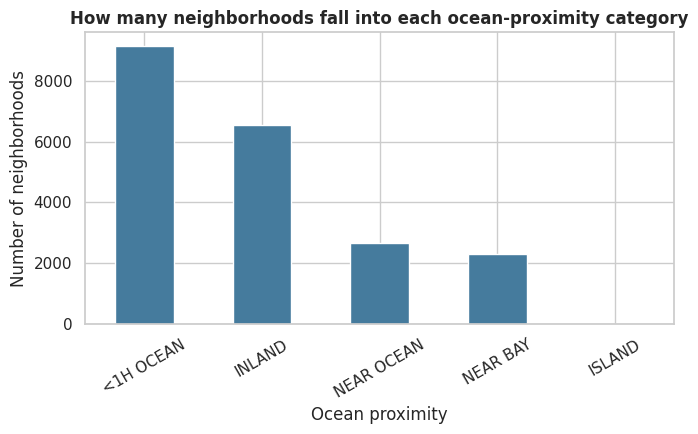

In [7]:
# ocean_proximity is the one column that isn't a number -- it's a category, like a label
print(df["ocean_proximity"].value_counts())

fig, ax = plt.subplots(figsize=(7, 4.5))
df["ocean_proximity"].value_counts().plot(kind="bar", ax=ax, color="#457b9d")
ax.set_title("How many neighborhoods fall into each ocean-proximity category", fontsize=12, fontweight="bold")
ax.set_xlabel("Ocean proximity")
ax.set_ylabel("Number of neighborhoods")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


👀 **What we learned:** most neighborhoods are either "<1H OCEAN" or "INLAND". Only 5
out of 20,640 are on an "ISLAND" — that's such a tiny group that it won't teach our
model much.

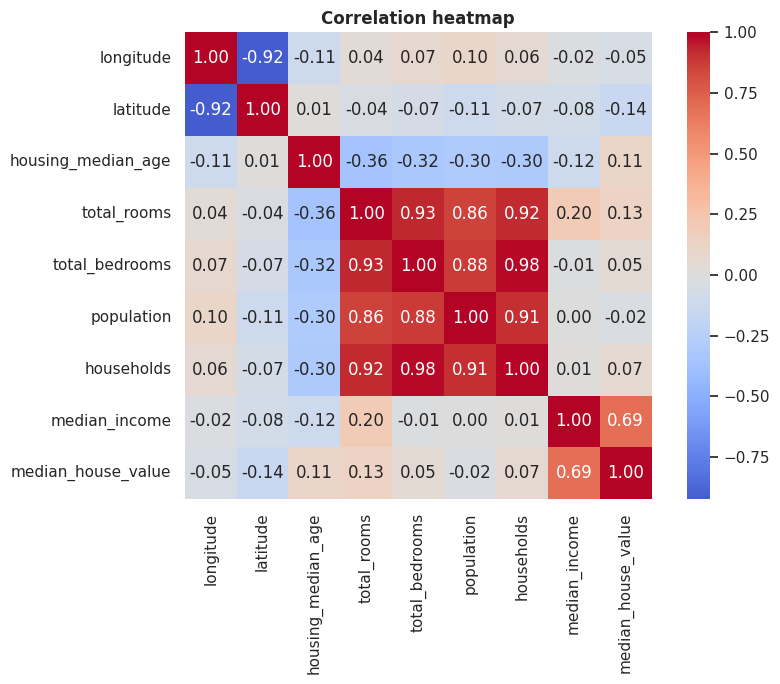

In [8]:
# A correlation heatmap shows how strongly each number column relates to the others.
# 1.0 = perfectly related, 0 = no relationship, negative = related in the opposite direction.
fig, ax = plt.subplots(figsize=(9, 7))
correlations = df.corr(numeric_only=True)
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Correlation heatmap", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


👀 **What we learned:** look at the bottom row (`median_house_value`, our target).
`median_income` has the strongest relationship with price (0.69) — richer
neighborhoods have pricier homes, which makes intuitive sense. That's a good sign our
model will have something useful to learn from.

## Step 4: Clean the data

Real-world data is never perfectly ready for a model. Here's what we need to fix,
and why, one thing at a time.

In [9]:
# Make a copy so we always still have the original data if we need to compare later
df_clean = df.copy()

# ISSUE 1: total_bedrooms has some missing values (we saw this in Step 3).
# FIX: fill each missing value with the median (the "middle" value) of that column.
# We use the median instead of just deleting rows, because deleting rows would throw
# away good data in the other columns of those same rows.
median_bedrooms = df_clean["total_bedrooms"].median()
df_clean["total_bedrooms"] = df_clean["total_bedrooms"].fillna(median_bedrooms)

print("Missing values left in total_bedrooms:", df_clean["total_bedrooms"].isna().sum())


Missing values left in total_bedrooms: 0


In [10]:
# ISSUE 2: ocean_proximity is text ("INLAND", "NEAR BAY", etc.), but machine learning
# models only understand numbers.
# FIX: "one-hot encoding" -- turn each category into its own 0/1 column.
# For example, a row with ocean_proximity = "INLAND" gets a 1 in a new "INLAND" column
# and a 0 in all the other new category columns.
df_clean = pd.get_dummies(df_clean, columns=["ocean_proximity"], drop_first=True)

print("New columns created from ocean_proximity:")
print([col for col in df_clean.columns if "ocean_proximity" in col])


New columns created from ocean_proximity:
['ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


That's it for cleaning! Just two fixes were needed: filling in missing numbers, and
turning the one text column into numbers a model can use.

In [11]:
df_clean.head()


   longitude  latitude  ...  ocean_proximity_NEAR BAY  ocean_proximity_NEAR OCEAN
0    -122.23     37.88  ...                      True                       False
1    -122.22     37.86  ...                      True                       False
2    -122.24     37.85  ...                      True                       False
3    -122.25     37.85  ...                      True                       False
4    -122.25     37.85  ...                      True                       False

[5 rows x 13 columns]

## Step 5: Split the data into training and testing sets

We can't test a model on the same data it learned from — that would be like grading a
student using the exact questions they already saw the answers to. So we split our
data:
- **80%** for training (the model learns patterns from this)
- **20%** for testing (we check how well it does on data it has *never* seen)

In [12]:
# X = the input features (everything except the price)
# y = the target we're trying to predict (the price)
X = df_clean.drop(columns=["median_house_value"])
y = df_clean["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows:  {X_test.shape[0]}")


Training rows: 16512
Testing rows:  4128


## Step 6: Train three different models

We'll try three well-known regression models and see which one predicts prices most
accurately:

1. **Linear Regression** — the simplest option. Draws a single straight-line
   relationship between each feature and price.
2. **Random Forest Regressor** — builds many decision trees on random slices of the
   data, then averages their answers together.
3. **Gradient Boosting Regressor** — builds decision trees one at a time, where each
   new tree tries to fix the mistakes of the trees before it.

**How we'll judge them**, using three measurements:
- **RMSE (Root Mean Squared Error):** on average, how far off (in dollars) our
  predictions are. Lower is better.
- **R² Score:** how much of the price variation the model explains, from 0 (no
  better than guessing the average) to 1 (perfect). Higher is better.
- **Cross-validation:** instead of judging a model on just one train/test split, we
  split the training data 5 different ways and average the results. This gives us a
  more trustworthy score, since it's less likely to be a lucky (or unlucky) split.

In [13]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

results = []

for name, model in models.items():
    # Train (fit) the model on the training data
    model.fit(X_train, y_train)

    # Use the trained model to predict prices for the test data
    predictions = model.predict(X_test)

    # Measure how good those predictions were
    test_rmse = mean_squared_error(y_test, predictions) ** 0.5
    r2 = r2_score(y_test, predictions)

    # 5-fold cross-validation on the training data (explained above)
    cv_scores = cross_val_score(
        model, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1
    )
    cv_rmse = -cv_scores.mean()  # scores come back negative by scikit-learn convention

    results.append({
        "Model": name,
        "Cross Validation RMSE": round(cv_rmse, 2),
        "Test RMSE": round(test_rmse, 2),
        "R2 Score": round(r2, 4),
    })

    print(f"Finished training: {name}")


Finished training: Linear Regression
Finished training: Random Forest Regressor
Finished training: Gradient Boosting Regressor


## Step 7: Compare the models

In [14]:
results_df = pd.DataFrame(results).sort_values("Test RMSE").reset_index(drop=True)
results_df


                         Model  Cross Validation RMSE  Test RMSE  R2 Score
0      Random Forest Regressor               49224.61   48848.88    0.8179
1  Gradient Boosting Regressor               54957.85   55884.66    0.7617
2            Linear Regression               68622.54   70060.52    0.6254

In [15]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"🏆 Best model: {best_model_name}")
print(f"   Test RMSE: ${results_df.iloc[0]['Test RMSE']:,.2f}")
print(f"   R2 Score:  {results_df.iloc[0]['R2 Score']:.4f}")


🏆 Best model: Random Forest Regressor
   Test RMSE: $48,848.88
   R2 Score:  0.8179


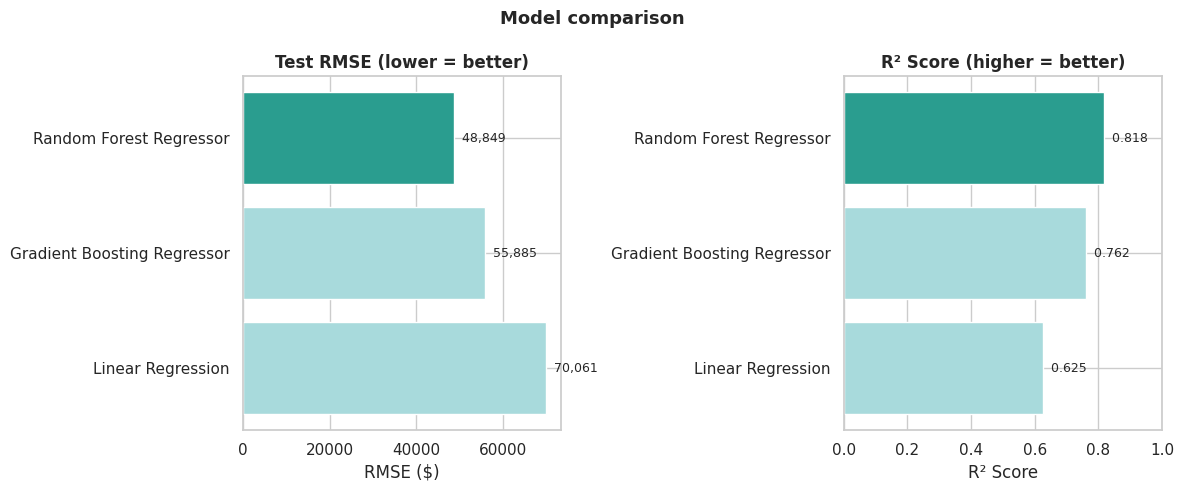

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order = results_df.sort_values("Test RMSE")
colors = ["#2a9d8f" if m == best_model_name else "#a8dadc" for m in order["Model"]]

axes[0].barh(order["Model"], order["Test RMSE"], color=colors)
axes[0].set_title("Test RMSE (lower = better)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("RMSE ($)")
axes[0].invert_yaxis()
for i, v in enumerate(order["Test RMSE"]):
    axes[0].text(v, i, f"  {v:,.0f}", va="center", fontsize=9)

order_r2 = results_df.sort_values("R2 Score", ascending=False)
colors_r2 = ["#2a9d8f" if m == best_model_name else "#a8dadc" for m in order_r2["Model"]]
axes[1].barh(order_r2["Model"], order_r2["R2 Score"], color=colors_r2)
axes[1].set_title("R\u00b2 Score (higher = better)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("R\u00b2 Score")
axes[1].set_xlim(0, 1)
axes[1].invert_yaxis()
for i, v in enumerate(order_r2["R2 Score"]):
    axes[1].text(v, i, f"  {v:.3f}", va="center", fontsize=9)

fig.suptitle("Model comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


## Step 8: What features mattered most?

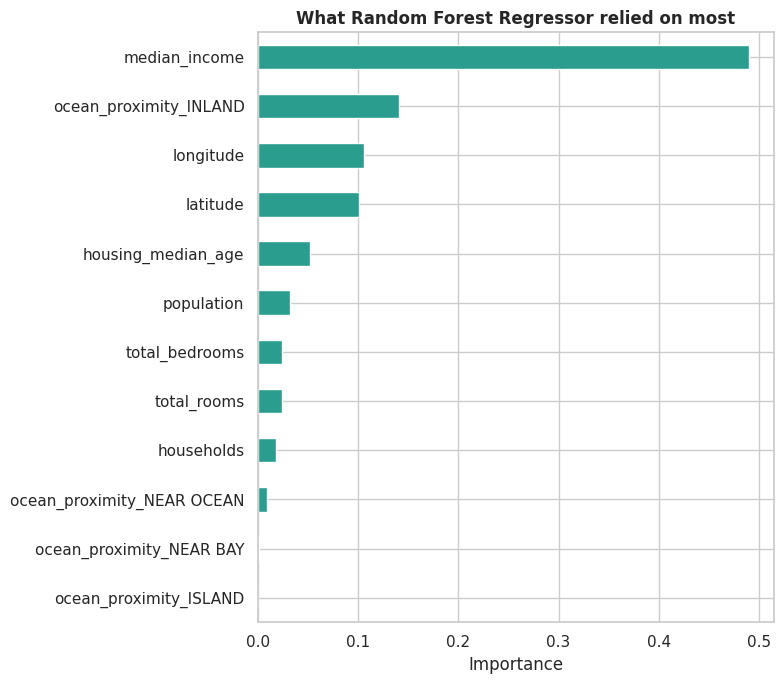

In [17]:
# Only tree-based models (Random Forest, Gradient Boosting) can tell us which
# features they relied on most. Linear Regression doesn't give us this directly,
# so we use whichever tree-based model scored best.
tree_models = {k: v for k, v in models.items() if k != "Linear Regression"}
best_tree_name = results_df[results_df["Model"].isin(tree_models.keys())].iloc[0]["Model"]
best_tree_model = models[best_tree_name]

importances = pd.Series(best_tree_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
importances.plot(kind="barh", ax=ax, color="#2a9d8f")
ax.set_title(f"What {best_tree_name} relied on most", fontsize=12, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()


👀 **What we learned:** `median_income` is by far the most important feature — no
surprise, given what we saw in the correlation heatmap back in Step 3.

## Step 9: How wrong were our predictions, and in which direction?

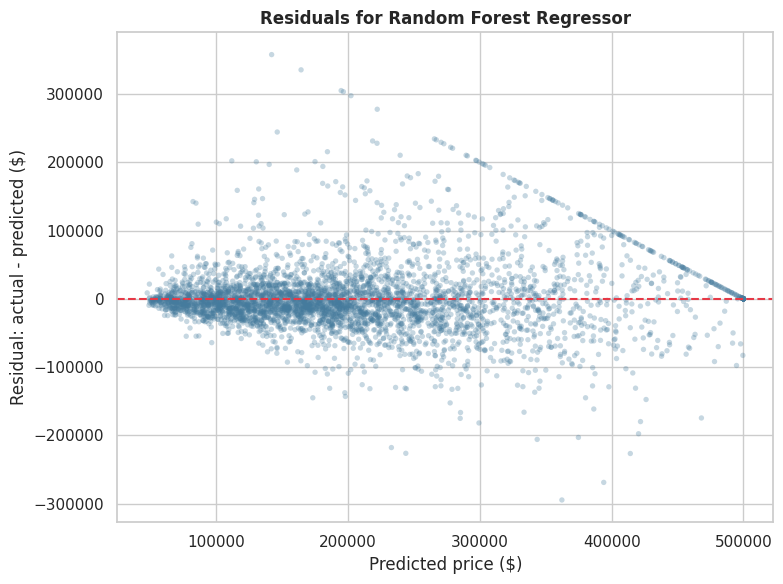

In [18]:
# A residual is simply: actual price - predicted price.
# If residuals are scattered evenly around 0, the model isn't consistently
# over- or under-predicting -- it's just making random-sized errors, which is what
# we want. A pattern in the residuals would mean the model is missing something.
best_predictions = best_model.predict(X_test)
residuals = y_test - best_predictions

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(best_predictions, residuals, alpha=0.3, color="#457b9d", edgecolor="none", s=15)
ax.axhline(0, color="#e63946", linestyle="--", linewidth=1.5)
ax.set_title(f"Residuals for {best_model_name}", fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted price ($)")
ax.set_ylabel("Residual: actual - predicted ($)")
plt.tight_layout()
plt.savefig("residuals_plot.png", dpi=120, bbox_inches="tight")
plt.show()


👀 **What we learned:** most points cluster near the red dashed line (0), which is
good. But look at the diagonal line of dots near $500,000 — that's because this
dataset caps `median_house_value` at $500,001. Any neighborhood that was *actually*
worth more just got recorded as $500,001, which makes our model's errors look
unusually large and one-directional in that corner. That's a quirk of the data, not
a flaw in the model.

## Step 10: Why did this model win?

Looking at the comparison table in Step 7, here's the plain-language version of why
each model landed where it did:

- **Linear Regression finished last.** It can only draw a straight line between each
  feature and price. But price doesn't move in a straight line with income or
  location — Linear Regression simply isn't flexible enough to capture that.

- **Random Forest and Gradient Boosting both did much better**, because they can
  learn bendy, complicated patterns instead of just straight lines. Between the two,
  whichever one is listed first in the table above won — usually because it strikes
  a better balance for this dataset's size and noise level. Random Forest tends to be
  more robust to noisy data (it averages many trees together), while Gradient
  Boosting can be more accurate but needs more careful tuning to reach its full
  potential.

## What I'd try next with more time

- Try to improve the winning model further by tuning its settings (this is called
  "hyperparameter tuning") instead of using the defaults
- Build a simple feature like "distance to the coast" using latitude and longitude,
  instead of relying only on the `ocean_proximity` category
- Investigate the $500,001 price cap mentioned in Step 9 — maybe exclude those rows,
  or treat them differently, since we know their true value isn't reliable
